In [18]:
import pandas as pd
import numpy as np
import joblib
import cargar_datos as cd
from pycaret.classification import setup
from sklearn.metrics import classification_report
from sklearn.model_selection import learning_curve,train_test_split,cross_validate
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.linear_model import RidgeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

import  matplotlib.pyplot as plt
from ft_engineering import processing_pipeline

### importing the data ###

In [3]:
df = cd.cargar_datos(r'C:\henrylocal\Module_5\MLops\base_de_datos.xlsx')


In [4]:
df = df.drop(['fecha_prestamo', 'tipo_credito','puntaje','cant_creditosvigentes','salario_cliente','saldo_mora_codeudor'] , axis = 1)


In [5]:
X = df.drop('Pago_atiempo', axis = 1)
y= df['Pago_atiempo']

#### Preparando los datos para el learning curve

In [6]:
num_features =['capital_prestado','plazo_meses','edad_cliente','total_otros_prestamos','cuota_pactada','puntaje_datacredito','huella_consulta','saldo_mora','saldo_total','saldo_principal','creditos_sectorFinanciero','creditos_sectorCooperativo','creditos_sectorReal','promedio_ingresos_datacredito']

nom_features = ['tipo_laboral']

or_features = ['tendencia_ingresos']

ti_order = ['Decreciente','Estable','Creciente']

for i in num_features:
    X[i] = X[i].apply(lambda x : x if isinstance(x,(int,float) )else np.nan)


X['tipo_laboral'] = X['tipo_laboral'].apply(lambda x : x if isinstance(x,str)  else np.nan)

X['puntaje_datacredito'] = X['puntaje_datacredito'].apply(lambda x: x if x >= 0 else np.nan)

X['tendencia_ingresos'] = X['tendencia_ingresos'].apply(lambda x : x if isinstance(x,str)  else np.nan)


In [7]:
X['tendencia_ingresos'].unique()

array(['Estable', 'Creciente', nan, 'Decreciente'], dtype=object)

#### Creando el setup para correr los modelos

In [8]:
exp = setup(
    data = df,
    target = 'Pago_atiempo',
    categorical_features= ['tipo_laboral','tendencia_ingresos'],
    numeric_features=['capital_prestado','plazo_meses','edad_cliente','total_otros_prestamos','cuota_pactada','puntaje_datacredito','huella_consulta','saldo_mora','saldo_total','saldo_principal','creditos_sectorFinanciero','creditos_sectorCooperativo','creditos_sectorReal','promedio_ingresos_datacredito'],
    session_id =42,
    verbose = False,
)

#### Entrenando todos los modelos de clasification y selecionando los 4 mejores modelos

In [9]:
best_models = exp.compare_models(n_select = 4 , fold = 5, sort = 'AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.9520,0.6650,0.9978,0.9539,0.9753,0.0557,0.1100,0.5260
ridge,Ridge Classifier,0.9523,0.6574,0.9996,0.9527,0.9756,0.0096,0.0339,0.0540
lda,Linear Discriminant Analysis,0.9527,0.6566,0.9992,0.9535,0.9758,0.0396,0.1082,0.0440
rf,Random Forest Classifier,0.9530,0.6532,0.9993,0.9536,0.9759,0.0449,0.1238,0.3700
xgboost,Extreme Gradient Boosting,0.9508,0.6384,0.9969,0.9535,0.9747,0.0385,0.0697,0.4140
lightgbm,Light Gradient Boosting Machine,0.9527,0.6376,0.9982,0.9543,0.9758,0.0708,0.1341,0.3100
ada,Ada Boost Classifier,0.9526,0.6350,0.9987,0.9537,0.9757,0.0485,0.1168,0.1840
lr,Logistic Regression,0.9525,0.6232,0.9996,0.9528,0.9757,0.0148,0.0505,1.7600
et,Extra Trees Classifier,0.9529,0.6232,0.9994,0.9533,0.9758,0.0350,0.1002,0.1980
qda,Quadratic Discriminant Analysis,0.7880,0.6144,0.8135,0.9571,0.8518,0.0746,0.0766,0.0480


In [10]:
# Mejores modelos segun pycaret #
best_models


[GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                            learning_rate=0.1, loss='log_loss', max_depth=3,
                            max_features=None, max_leaf_nodes=None,
                            min_impurity_decrease=0.0, min_samples_leaf=1,
                            min_samples_split=2, min_weight_fraction_leaf=0.0,
                            n_estimators=100, n_iter_no_change=None,
                            random_state=42, subsample=1.0, tol=0.0001,
                            validation_fraction=0.1, verbose=0,
                            warm_start=False),
 RidgeClassifier(alpha=1.0, class_weight=None, copy_X=True, fit_intercept=True,
                 max_iter=None, positive=False, random_state=42, solver='auto',
                 tol=0.0001),
 LinearDiscriminantAnalysis(covariance_estimator=None, n_components=None,
                            priors=None, shrinkage=None, solver='svd',
                            store_

#### Evaluando el desempeños de los 4 mejores modelos obtenidoes  cn pycaret:
    Criterio: modelo con mayor accuracy y menor desviación

In [22]:
all_models =  ['gbc','ridge','lda','rf']

results = []

# Loop through every model
for model_id in all_models:
    try:
        print(f"Training {model_id}...")

        # Train model with cross-validation
        model = exp.create_model(model_id, verbose=False)

        # Get CV results
        cv_results = exp.pull()

        results.append({
            "nombre": model_id,
            "modelo": model,

            "accuracy_avg": cv_results["Accuracy"].mean(),
            "accuracy_std": cv_results["Accuracy"].std(),

            "precision_avg": cv_results["Prec."].mean(),
            "precision_std": cv_results["Prec."].std(),

            "recall_avg": cv_results["Recall"].mean(),
            "recall_std": cv_results["Recall"].std(),

            "f1_score_avg": cv_results["F1"].mean(),
            "f1_score_std": cv_results["F1"].std()
        })
    except Exception as e:
        print(f"Skipping {model_id}: {e}")
    

Training gbc...
Training ridge...
Training lda...
Training rf...


### Evaluación de los 4 modelos en el hold-out de pycaret test

In [24]:
all_models =  ['gbc','ridge','lda','rf']

results_0= []

for model_id in all_models:
    try:
        print(f"Training {model_id}...")

        # Train with PyCaret CV
        model = exp.create_model(model_id, verbose=False)

        # Predict on PyCaret holdout set
        predictions = exp.predict_model(model, verbose=False)

        y_true = predictions["Pago_atiempo"]
        y_pred = predictions["prediction_label"]

        report = classification_report(
            y_true,
            y_pred,
            output_dict=True
        )

        results_0.append({
            "nombre": model_id,
            "modelo": model,

            # Class 0
            "precision_class_0": report["0"]["precision"],
            "recall_class_0": report["0"]["recall"],
            "f1_class_0": report["0"]["f1-score"],

            # Class 1
            "precision_class_1": report["1"]["precision"],
            "recall_class_1": report["1"]["recall"],
            "f1_class_1": report["1"]["f1-score"],

            # Overall
            "accuracy": report["accuracy"]
        })

    except Exception as e:
        print(f"Skipping {model_id}: {e}")

Training gbc...
Training ridge...
Training lda...
Training rf...


In [23]:
#### Mejor modelo basado en accuracy y variación
Best_model = max(results,key = lambda x: x['accuracy_avg']- x['accuracy_std'])
Best_model

{'nombre': 'rf',
 'modelo': RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                        criterion='gini', max_depth=None, max_features='sqrt',
                        max_leaf_nodes=None, max_samples=None,
                        min_impurity_decrease=0.0, min_samples_leaf=1,
                        min_samples_split=2, min_weight_fraction_leaf=0.0,
                        monotonic_cst=None, n_estimators=100, n_jobs=-1,
                        oob_score=False, random_state=42, verbose=0,
                        warm_start=False),
 'accuracy_avg': 0.8739750000000001,
 'accuracy_std': 0.2747313634178932,
 'precision_avg': 0.874375,
 'precision_std': 0.2749189173854059,
 'recall_avg': 0.916225,
 'recall_std': 0.2882539793149595,
 'f1_score_avg': 0.894775,
 'f1_score_std': 0.281530276508423}

### Analizando la curva de aprendizaje de cada modelo #

In [13]:

# spliting into training and test#
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size= 0.2, random_state= True, stratify= y)
# getting the preprocessor ready with the features #
preprocesor = processing_pipeline(num_features,nom_features,or_features,ti_order)


x_train_preprocessed = preprocesor.fit_transform(x_train)
x_test_preprocessed = preprocesor.transform(x_test)

### después de analizar el AUC, el accuracy con la vairación y observar el comportamiento de los 4 mejores modelos en la curva de aprendizaje se determinó que el mejor modelo es:
    RandomForesClassifier:
    AUC :0.6532
    accuracy_avg : 0.8739750000000001
    accuracy_std: 0.2747313634178932,
    precision_avg: 0.874375,
    precision_std: 0.2749189173854059,
    recall_avg: 0.916225,
    recall_std: 0.2882539793149595,
    f1_score_avg: 0.894775,
    f1_score_std: 0.281530276508423
### Resultado obtenidoes en el set de test
    RandomForestClassifier

    'precision_class_0': 0.6,
    'recall_class_0': 0.0196078431372549,
    'f1_class_0': 0.0379746835443038,
    'precision_class_1': 0.9534739454094293,
    'recall_class_1': 0.9993498049414824,
    'f1_class_1': 0.9758730158730159,
    'accuracy': 0.9529266026633633

This is the learning curve for model: GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.1, loss='log_loss', max_depth=3,
                           max_features=None, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_samples_leaf=1,
                           min_samples_split=2, min_weight_fraction_leaf=0.0,
                           n_estimators=100, n_iter_no_change=None,
                           random_state=42, subsample=1.0, tol=0.0001,
                           validation_fraction=0.1, verbose=0,
                           warm_start=False)


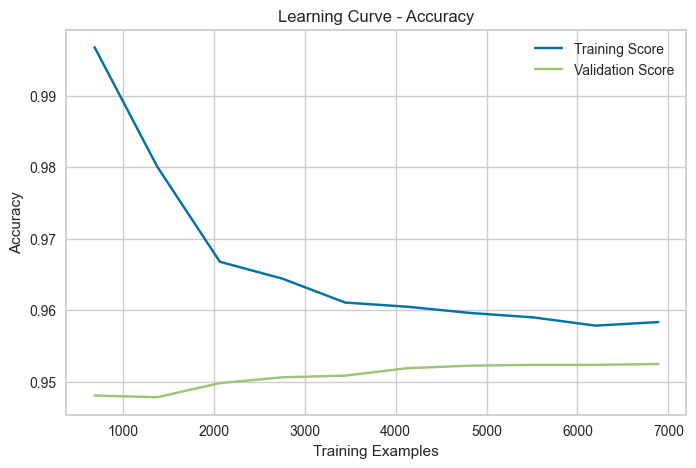

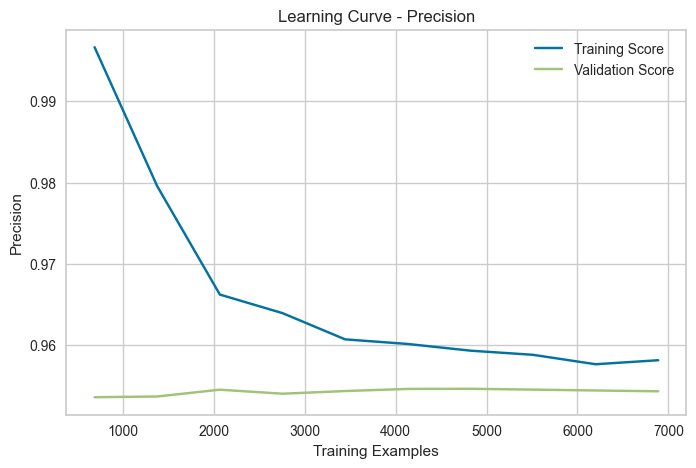

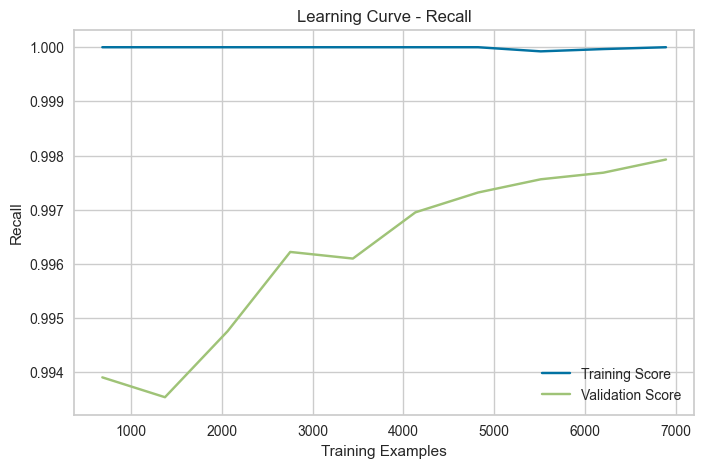

This is the learning curve for model: RidgeClassifier(alpha=1.0, class_weight=None, copy_X=True, fit_intercept=True,
                max_iter=None, positive=False, random_state=42, solver='auto',
                tol=0.0001)


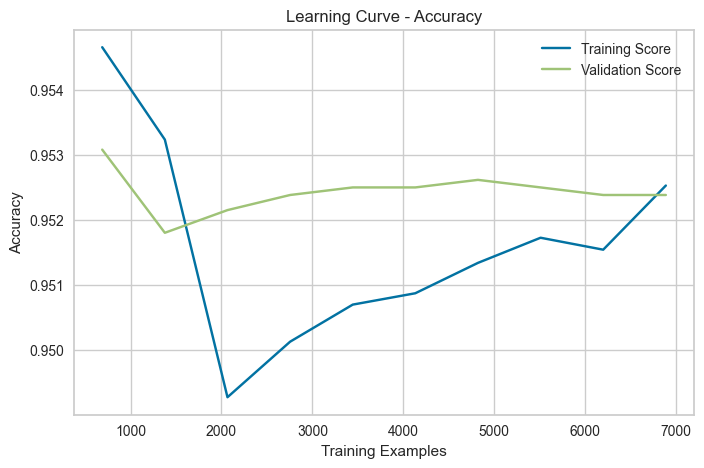

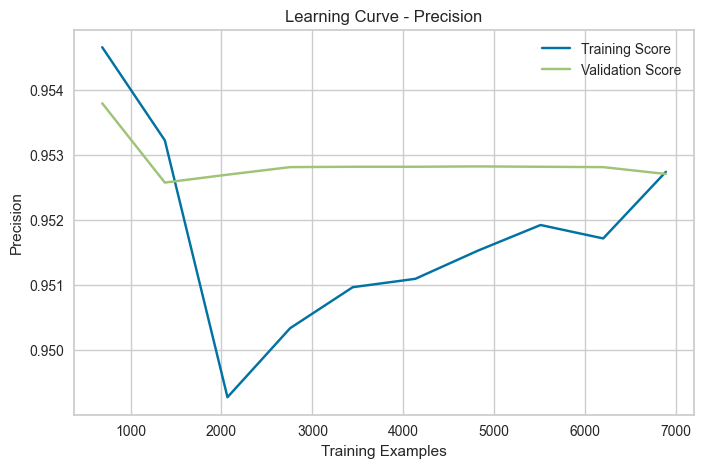

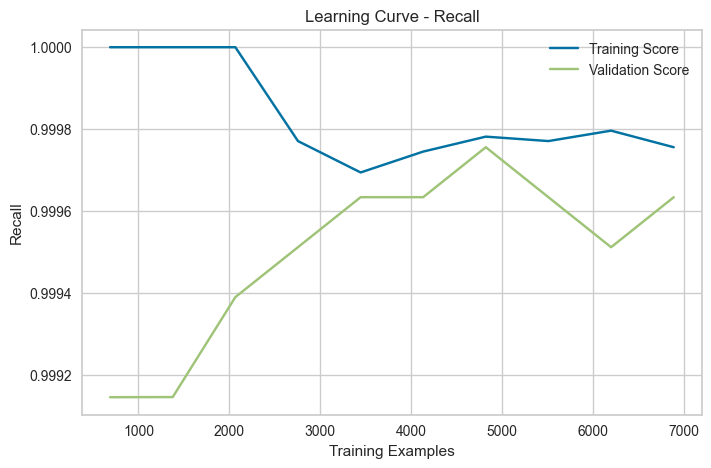

This is the learning curve for model: LinearDiscriminantAnalysis(covariance_estimator=None, n_components=None,
                           priors=None, shrinkage=None, solver='svd',
                           store_covariance=False, tol=0.0001)


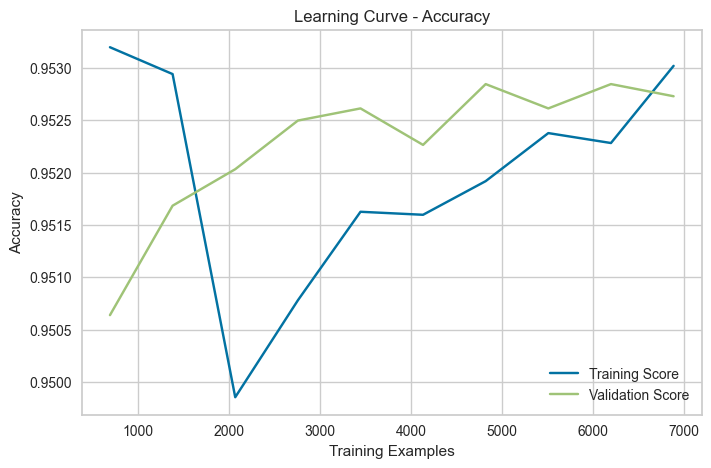

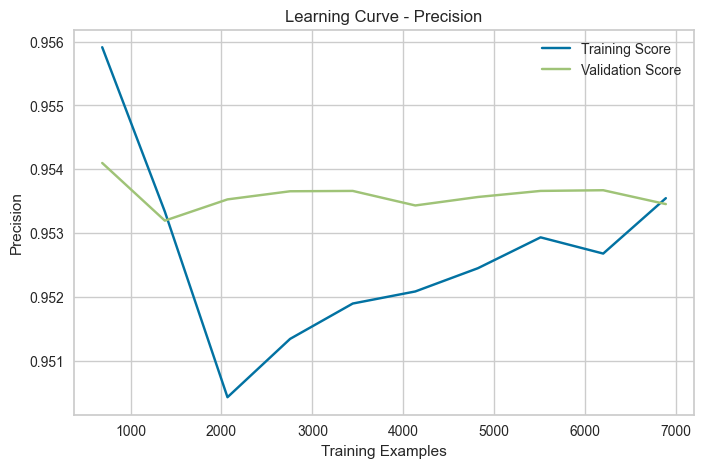

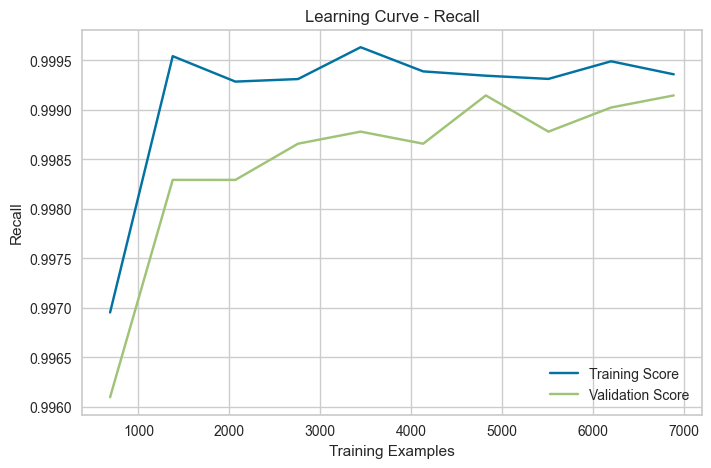

This is the learning curve for model: RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=100, n_jobs=-1,
                       oob_score=False, random_state=42, verbose=0,
                       warm_start=False)


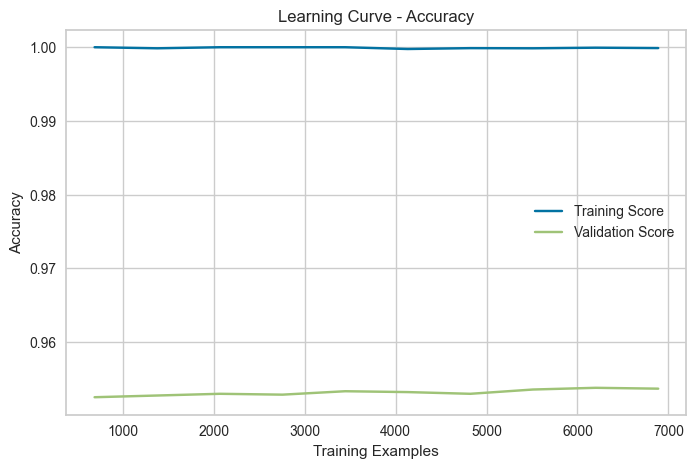

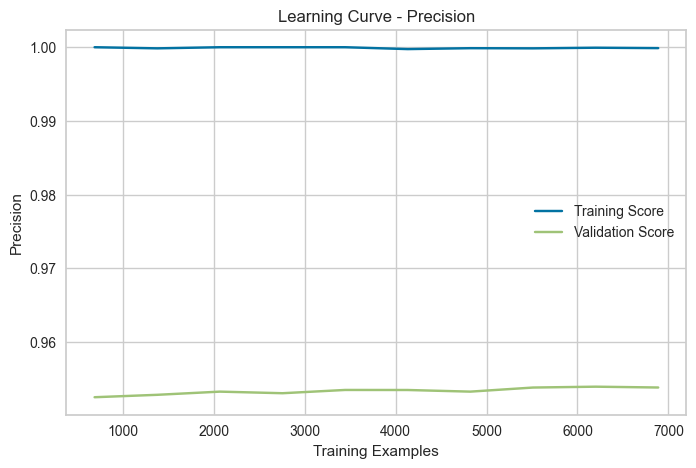

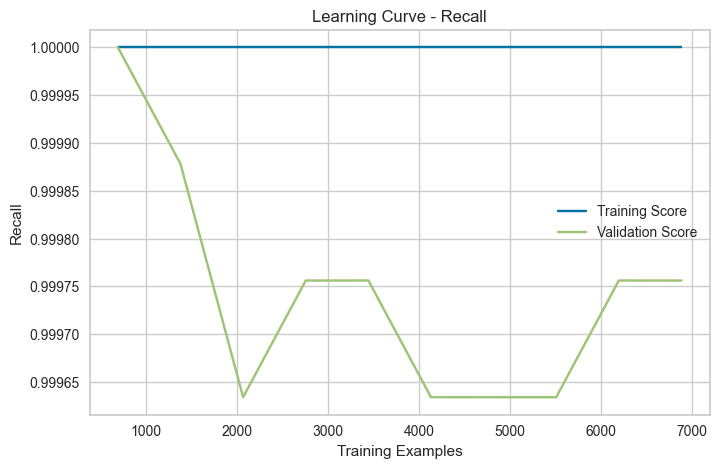

In [15]:
metrics = {
    "Accuracy": "accuracy",
    "Precision": "precision",
    "Recall": "recall"
}

for model in best_models:
    print(f"This is the learning curve for model: {model}")

    for metric_name, metric in metrics.items():

        train_sizes, train_scores, val_scores = learning_curve(
            estimator=model,
            X=x_train_preprocessed,
            y=y_train,
            cv=5,
            scoring=metric,
            train_sizes=np.linspace(0.1, 1.0, 10)
        )

        train_mean = train_scores.mean(axis=1)
        val_mean = val_scores.mean(axis=1)

        plt.figure(figsize=(8,5))
        plt.plot(train_sizes, train_mean, label="Training Score")
        plt.plot(train_sizes, val_mean, label="Validation Score")

        plt.xlabel("Training Examples")
        plt.ylabel(metric_name)
        plt.title(f"Learning Curve - {metric_name}")
        plt.legend()
        plt.grid(True)
        plt.show()